In [2]:
# import system libs
import os
import time
import shutil
import pathlib
import itertools
from PIL import Image

# import data handling tools
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

print ('modules loaded')

modules loaded


In [3]:
data_dir = r"C:\Users\vivek\blood_cancer_detection\bloodcells_dataset"
filepaths = []
labels = []

folds = os.listdir(data_dir)
for fold in folds:
    foldpath = os.path.join(data_dir, fold)
    filelist = os.listdir(foldpath)
    if fold in ['ig', 'neutrophil']:
        continue
    for file in filelist:
        fpath = os.path.join(foldpath, file)
        
        filepaths.append(fpath)
        labels.append(fold)

# Concatenate data paths with labels into one dataframe
Fseries = pd.Series(filepaths, name= 'filepaths')
Lseries = pd.Series(labels, name='labels')
df = pd.concat([Fseries, Lseries], axis= 1)

In [4]:
df.head()

,filepaths,labels
0,C:\Users\vivek\blood_cancer_detection\bloodcel...,basophil
1,C:\Users\vivek\blood_cancer_detection\bloodcel...,basophil
2,C:\Users\vivek\blood_cancer_detection\bloodcel...,basophil
3,C:\Users\vivek\blood_cancer_detection\bloodcel...,basophil
4,C:\Users\vivek\blood_cancer_detection\bloodcel...,basophil


In [5]:
df.shape

(10869, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10869 entries, 0 to 10868
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   filepaths  10869 non-null  object
 1   labels     10869 non-null  object
dtypes: object(2)
memory usage: 170.0+ KB


In [7]:
labelscount = df['labels'].value_counts().reset_index()
labelscount

,labels,count
0,eosinophil,3117
1,platelet,2348
2,erythroblast,1551
3,monocyte,1420
4,basophil,1219
5,lymphocyte,1214


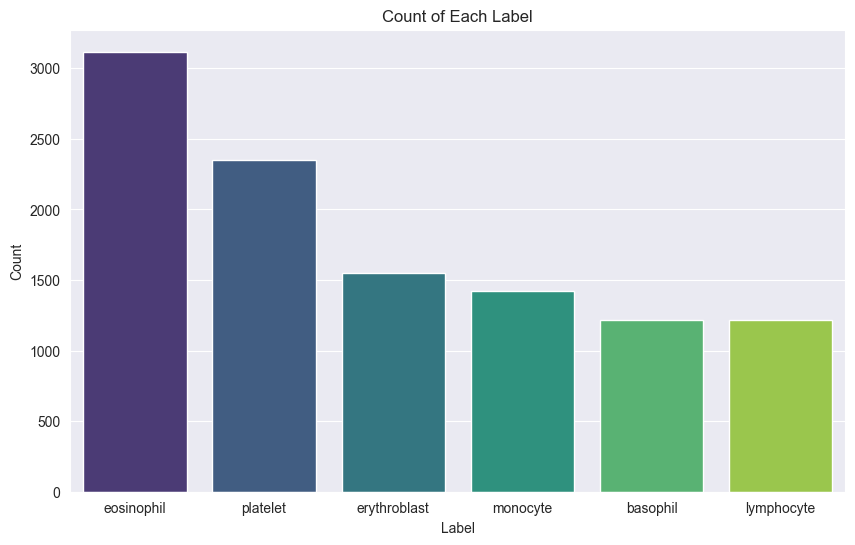

In [8]:
# Create a bar plot using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='labels', y='count', data=labelscount, palette='viridis')

# Add title and labels
plt.title('Count of Each Label')
plt.xlabel('Label')
plt.ylabel('Count')

# Show the plot
plt.show()

In [9]:
df

,filepaths,labels
0,C:\Users\vivek\blood_cancer_detection\bloodcel...,basophil
1,C:\Users\vivek\blood_cancer_detection\bloodcel...,basophil
2,C:\Users\vivek\blood_cancer_detection\bloodcel...,basophil
3,C:\Users\vivek\blood_cancer_detection\bloodcel...,basophil
4,C:\Users\vivek\blood_cancer_detection\bloodcel...,basophil
...,...,...
10864,C:\Users\vivek\blood_cancer_detection\bloodcel...,platelet
10865,C:\Users\vivek\blood_cancer_detection\bloodcel...,platelet
10866,C:\Users\vivek\blood_cancer_detection\bloodcel...,platelet
10867,C:\Users\vivek\blood_cancer_detection\bloodcel...,platelet


In [10]:
# train dataframe
train_df, dummy_df = train_test_split(df,  test_size= 0.2, shuffle= True, random_state= 43)

# valid and test dataframe
valid_df, test_df = train_test_split(dummy_df,  train_size= 0.5, shuffle= True, random_state= 43)

In [11]:
train_df

,filepaths,labels
1275,C:\Users\vivek\blood_cancer_detection\bloodcel...,eosinophil
3177,C:\Users\vivek\blood_cancer_detection\bloodcel...,eosinophil
3432,C:\Users\vivek\blood_cancer_detection\bloodcel...,eosinophil
4289,C:\Users\vivek\blood_cancer_detection\bloodcel...,eosinophil
4949,C:\Users\vivek\blood_cancer_detection\bloodcel...,erythroblast
...,...,...
2064,C:\Users\vivek\blood_cancer_detection\bloodcel...,eosinophil
10517,C:\Users\vivek\blood_cancer_detection\bloodcel...,platelet
7985,C:\Users\vivek\blood_cancer_detection\bloodcel...,monocyte
2303,C:\Users\vivek\blood_cancer_detection\bloodcel...,eosinophil


In [12]:
dummy_df

,filepaths,labels
9196,C:\Users\vivek\blood_cancer_detection\bloodcel...,platelet
615,C:\Users\vivek\blood_cancer_detection\bloodcel...,basophil
9606,C:\Users\vivek\blood_cancer_detection\bloodcel...,platelet
3977,C:\Users\vivek\blood_cancer_detection\bloodcel...,eosinophil
8990,C:\Users\vivek\blood_cancer_detection\bloodcel...,platelet
...,...,...
3091,C:\Users\vivek\blood_cancer_detection\bloodcel...,eosinophil
7850,C:\Users\vivek\blood_cancer_detection\bloodcel...,monocyte
3014,C:\Users\vivek\blood_cancer_detection\bloodcel...,eosinophil
7278,C:\Users\vivek\blood_cancer_detection\bloodcel...,monocyte


In [13]:
batch_size = 16
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator()
ts_gen = ImageDataGenerator()

train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

valid_gen = ts_gen.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= False, batch_size= batch_size)

Found 8694 validated image filenames belonging to 6 classes.
Found 1087 validated image filenames belonging to 6 classes.
Found 1087 validated image filenames belonging to 6 classes.


In [14]:
print("Train shape:", train_gen.image_shape)
print("Valid shape:", valid_gen.image_shape)


Train shape: (224, 224, 3)
Valid shape: (224, 224, 3)


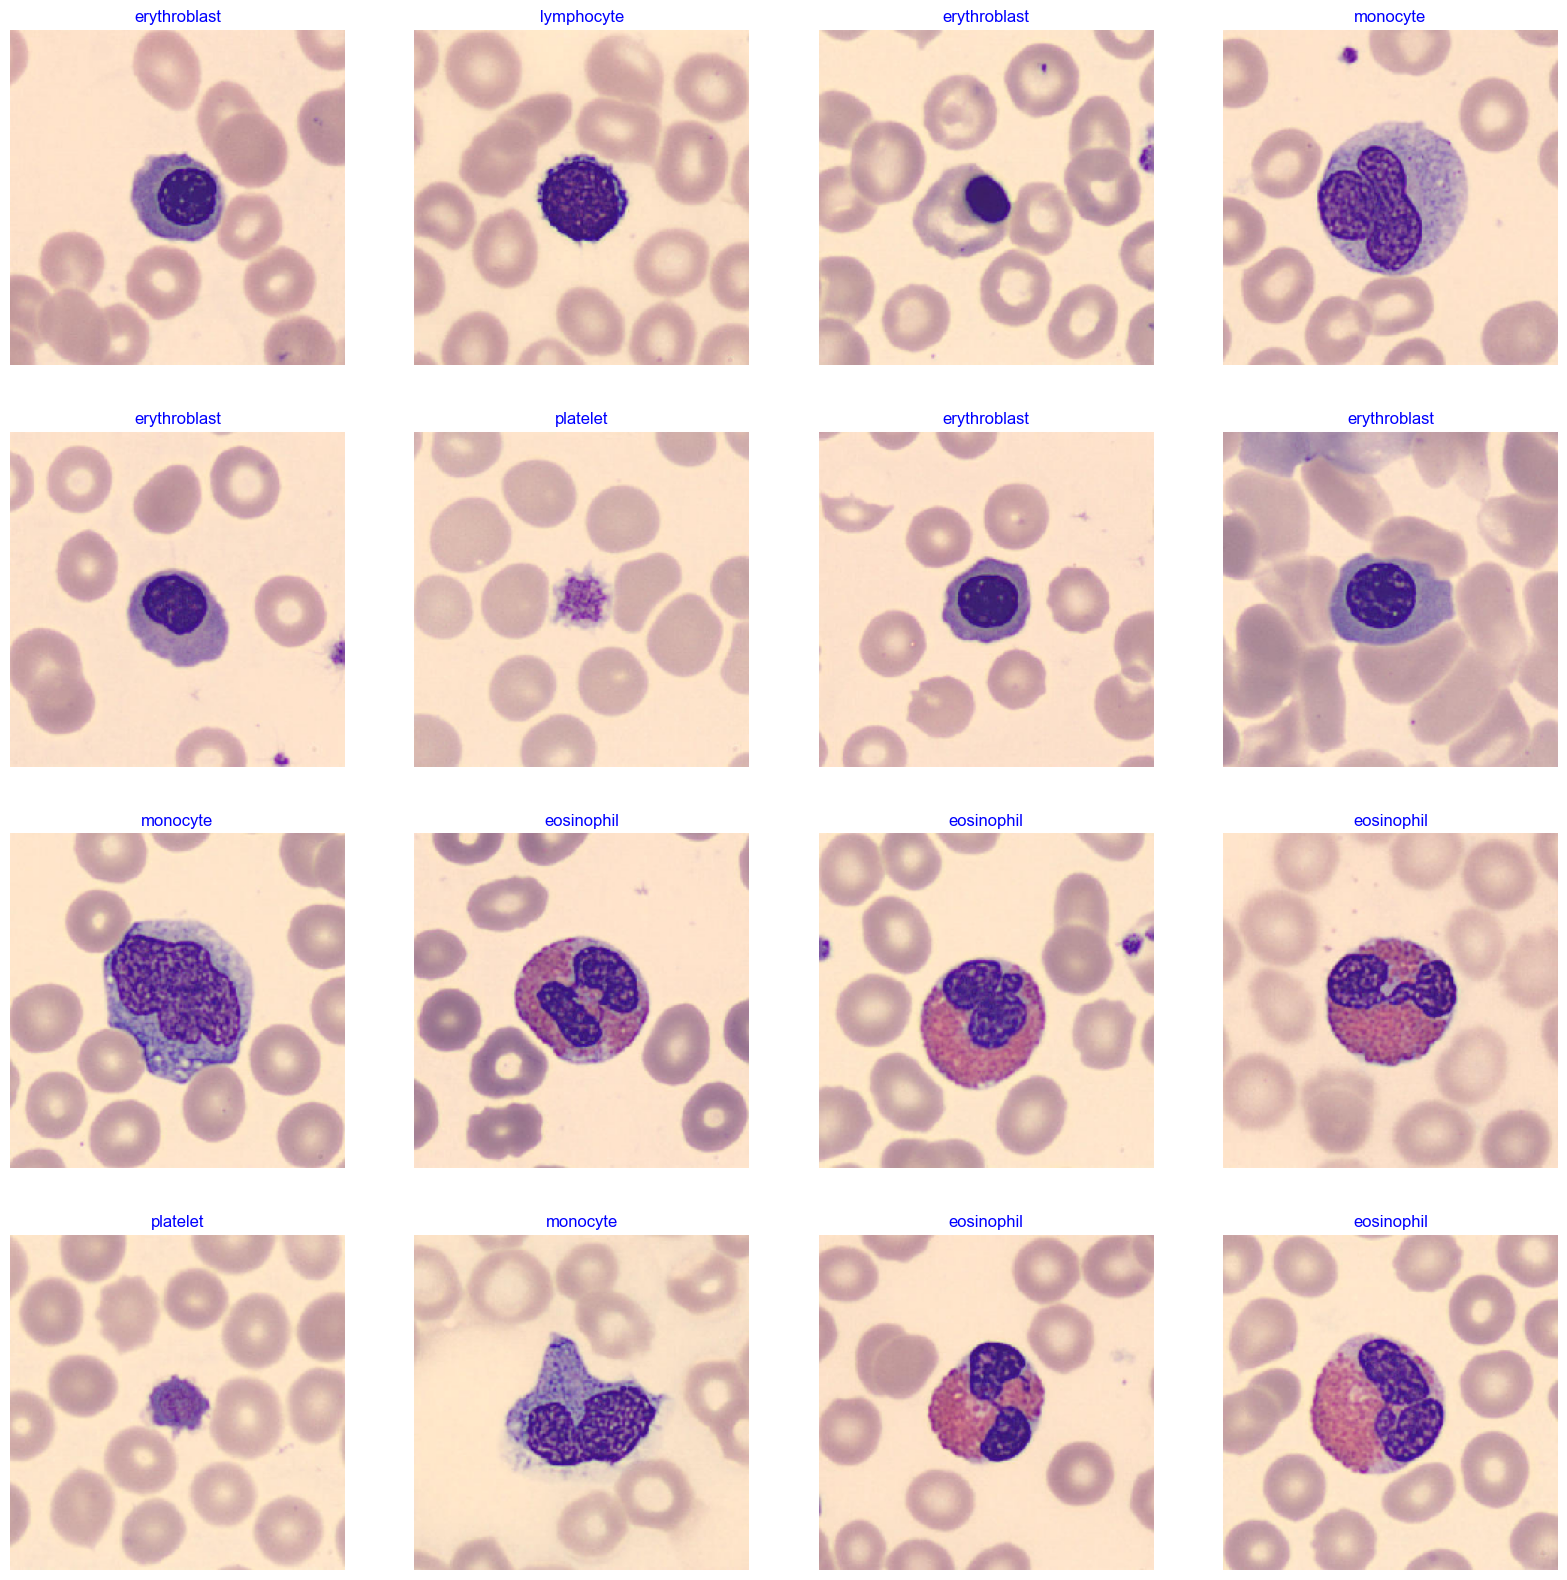

In [15]:
g_dict = train_gen.class_indices      # defines dictionary {'class': index}
classes = list(g_dict.keys())       # defines list of dictionary's kays (classes), classes names : string
images, labels = next(train_gen)      # get a batch size samples from the generator

plt.figure(figsize= (20, 20))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    image = images[i] / 255       # scales data to range (0 - 255)
    plt.imshow(image)
    index = np.argmax(labels[i])  # get image index
    class_name = classes[index]   # get class of image
    plt.title(class_name, color= 'blue', fontsize= 12)
    plt.axis('off')
plt.show()

In [16]:
class_count = len(list(train_gen.class_indices.keys())) # to define number of classes in dense layer #build cnn model
model = Sequential([
    tf.keras.Input(shape=(img_size[0], img_size[1], channels)),
    tf.keras.layers.Rescaling(1./255),  # Rescale input values to [0, 1] 
    
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(class_count, activation='softmax')
])

model.compile(Adamax(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy']) 

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(train_gen, epochs= 6, verbose= 1, validation_data= valid_gen, shuffle = False)

Epoch 1/6
544/544 ━━━━━━━━━━━━━━━━━━━━ 251s 458ms/step - accuracy: 0.7912 - loss: 0.6055 - val_accuracy: 0.9273 - val_loss: 0.2217
Epoch 2/6
544/544 ━━━━━━━━━━━━━━━━━━━━ 261s 456ms/step - accuracy: 0.9443 - loss: 0.1748 - val_accuracy: 0.9623 - val_loss: 0.1239
Epoch 3/6
544/544 ━━━━━━━━━━━━━━━━━━━━ 261s 453ms/step - accuracy: 0.9607 - loss: 0.1139 - val_accuracy: 0.9604 - val_loss: 0.1125
Epoch 4/6
544/544 ━━━━━━━━━━━━━━━━━━━━ 248s 455ms/step - accuracy: 0.9753 - loss: 0.0815 - val_accuracy: 0.9696 - val_loss: 0.0888
Epoch 5/6
544/544 ━━━━━━━━━━━━━━━━━━━━ 275s 479ms/step - accuracy: 0.9785 - loss: 0.0616 - val_accuracy: 0.9632 - val_loss: 0.1290
Epoch 6/6
544/544 ━━━━━━━━━━━━━━━━━━━━ 259s 473ms/step - accuracy: 0.9838 - loss: 0.0509 - val_accuracy: 0.9724 - val_loss: 0.0791


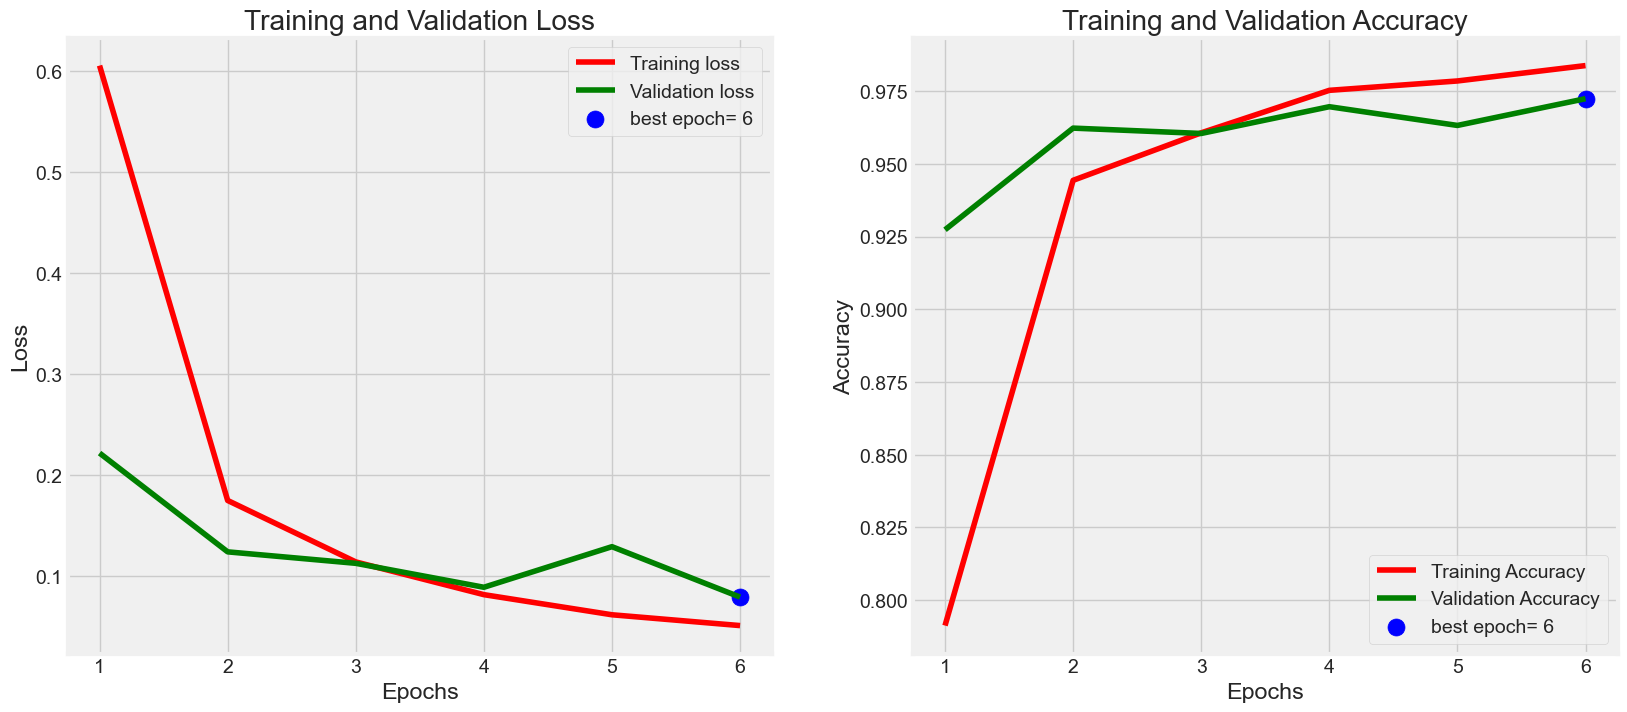

In [19]:
# Define needed variables
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [20]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

1087/1087 ━━━━━━━━━━━━━━━━━━━━ 69s 63ms/step - accuracy: 0.9848 - loss: 0.0460  
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9724 - loss: 0.0791    
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9706 - loss: 0.0912    
Train Loss:  0.04599126800894737
Train Accuracy:  0.9848170876502991
--------------------
Validation Loss:  0.07908917963504791
Validation Accuracy:  0.9724010825157166
--------------------
Test Loss:  0.09119894355535507
Test Accuracy:  0.9705612063407898


In [21]:
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step


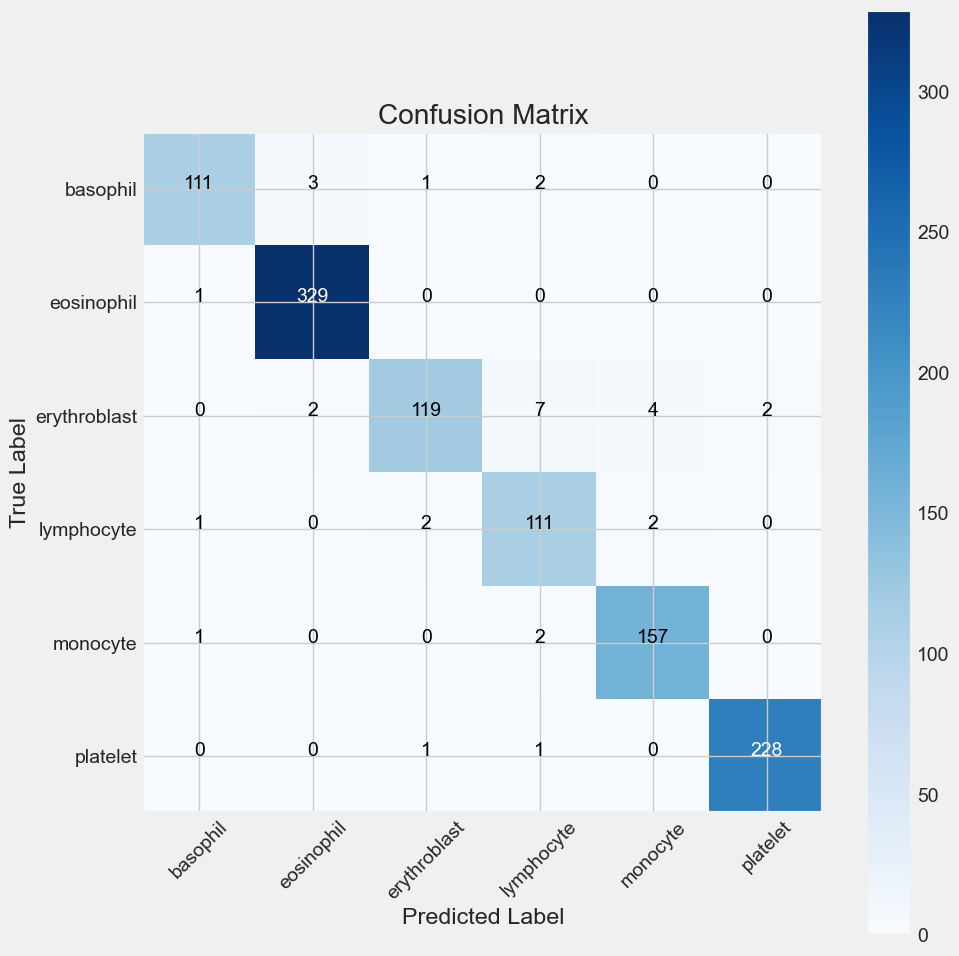

In [22]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [23]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true = test_gen.classes
num_classes = len(test_gen.class_indices)

y_true_bin = label_binarize(y_true, classes=range(num_classes))

68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step


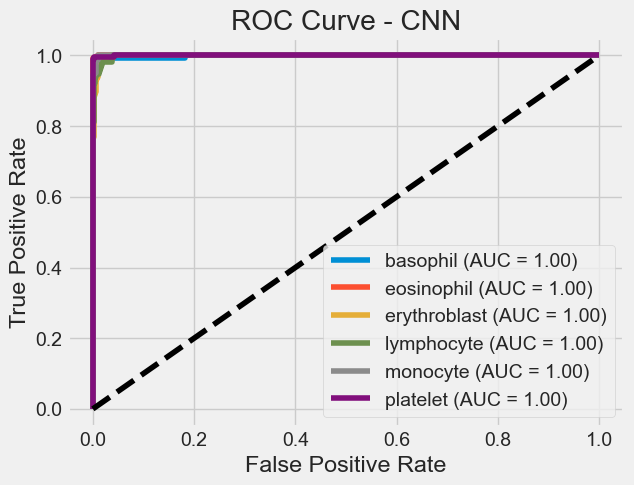

In [24]:
# get prediction probabilities
y_prob = model.predict(test_gen)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()

class_names = list(train_gen.class_indices.keys())

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CNN")
plt.legend()
plt.show()

In [25]:
print(classification_report(test_gen.classes, y_pred, target_names= classes))

              precision    recall  f1-score   support

    basophil       0.97      0.95      0.96       117
  eosinophil       0.99      1.00      0.99       330
erythroblast       0.97      0.89      0.93       134
  lymphocyte       0.90      0.96      0.93       116
    monocyte       0.96      0.98      0.97       160
    platelet       0.99      0.99      0.99       230

    accuracy                           0.97      1087
   macro avg       0.96      0.96      0.96      1087
weighted avg       0.97      0.97      0.97      1087



In [26]:
print("Generator image shape:", train_gen.image_shape)


Generator image shape: (224, 224, 3)


In [27]:
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys())) # to define number of classes in dense layer

# create pre-trained model (you can build on pretrained model such as : efficientnet, VGG, Resnet)
# we will use efficientnetb3 from EfficientNet family.
base_model = tf.keras.applications.EfficientNetB3(include_top=False, weights="imagenet", input_shape=img_shape, pooling='max')
# base_model.trainable = False

model = Sequential([
    base_model,
    BatchNormalization(momentum=0.99, epsilon=0.001),
    Dense(256, kernel_regularizer=regularizers.l2(0.016), activity_regularizer=regularizers.l1(0.006),
          bias_regularizer=regularizers.l1(0.006), activation='relu'),
    Dropout(rate=0.45, seed=123),
    Dense(class_count, activation='softmax')
])

model.compile(Adamax(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# model.summary()

In [27]:
model.build(input_shape=(None, *img_shape))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)          │ (None, 1536)                │      10,783,535 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1536)                │           6,144 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         393,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,184,693 (42.67 MB)

 Trainable params: 11,094,318 (42.32 MB)

 Non-trainable params: 90,375 (353.03 KB)

In [28]:
history = model.fit(train_gen, epochs= 6, verbose= 1, validation_data= valid_gen, shuffle= False)

Epoch 1/6
544/544 ━━━━━━━━━━━━━━━━━━━━ 1945s 3s/step - accuracy: 0.6745 - loss: 7.3592 - val_accuracy: 0.9365 - val_loss: 4.8704
Epoch 2/6
544/544 ━━━━━━━━━━━━━━━━━━━━ 1971s 4s/step - accuracy: 0.8773 - loss: 3.7228 - val_accuracy: 0.9604 - val_loss: 2.5453
Epoch 3/6
544/544 ━━━━━━━━━━━━━━━━━━━━ 1930s 3s/step - accuracy: 0.9087 - loss: 2.0818 - val_accuracy: 0.9227 - val_loss: 1.4442
Epoch 4/6
544/544 ━━━━━━━━━━━━━━━━━━━━ 1934s 4s/step - accuracy: 0.9228 - loss: 1.3483 - val_accuracy: 0.9917 - val_loss: 0.9417
Epoch 5/6
544/544 ━━━━━━━━━━━━━━━━━━━━ 2012s 4s/step - accuracy: 0.9286 - loss: 1.0132 - val_accuracy: 0.9834 - val_loss: 0.7651
Epoch 6/6
544/544 ━━━━━━━━━━━━━━━━━━━━ 2072s 4s/step - accuracy: 0.9363 - loss: 0.8397 - val_accuracy: 0.9917 - val_loss: 0.6162


In [29]:
model.save("efficientnetb3_model.keras")

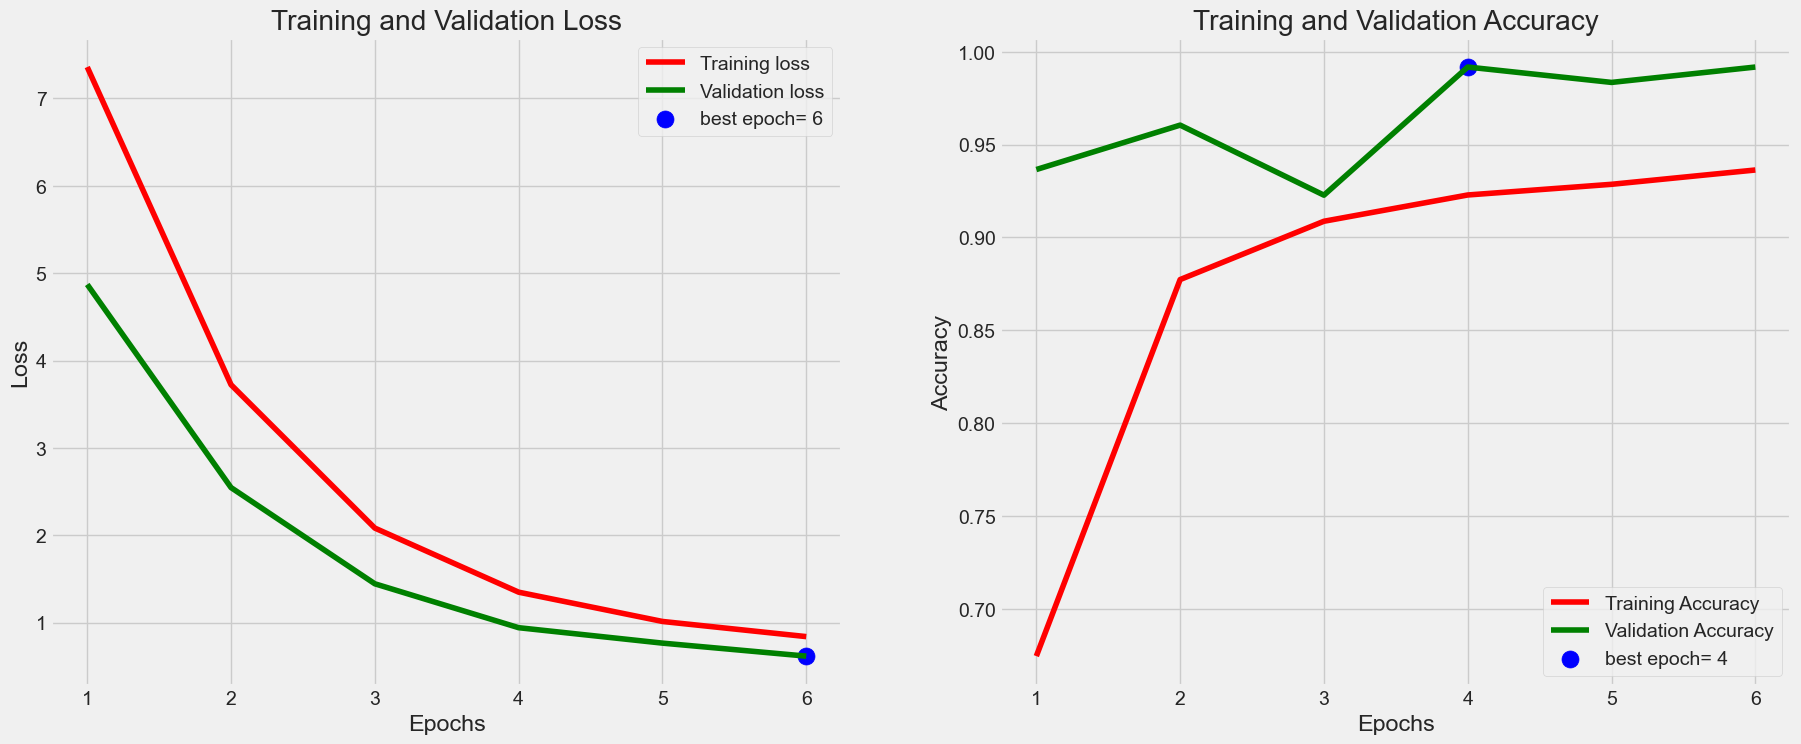

In [30]:
# Define needed variables
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [31]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

1087/1087 ━━━━━━━━━━━━━━━━━━━━ 433s 398ms/step - accuracy: 0.9968 - loss: 0.6178
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 51s 46ms/step - accuracy: 0.9917 - loss: 0.6162   
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 51s 46ms/step - accuracy: 0.9954 - loss: 0.6155   
Train Loss:  0.6177607178688049
Train Accuracy:  0.9967793822288513
--------------------
Validation Loss:  0.6161877512931824
Validation Accuracy:  0.9917203187942505
--------------------
Test Loss:  0.6154906749725342
Test Accuracy:  0.9954001903533936


In [32]:
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

68/68 ━━━━━━━━━━━━━━━━━━━━ 66s 930ms/step


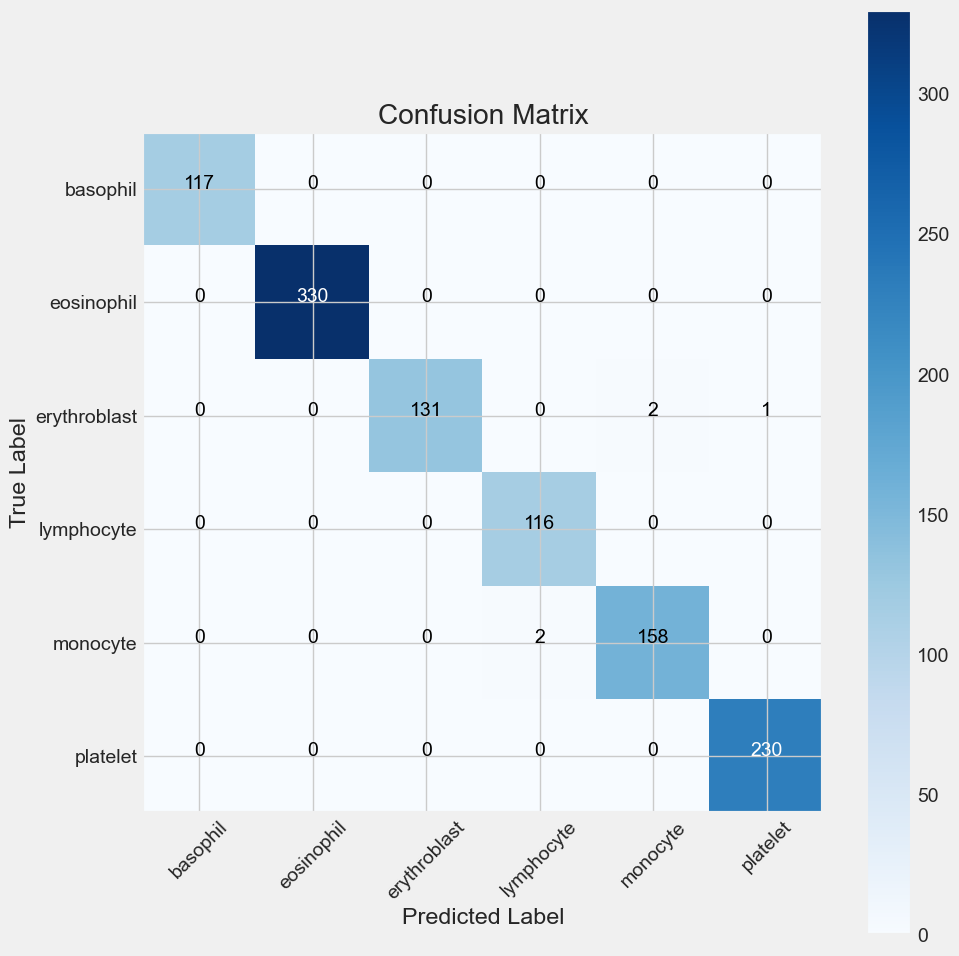

In [33]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

68/68 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step


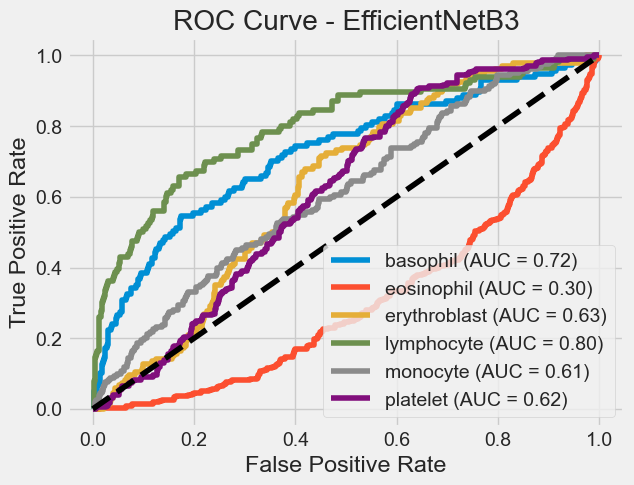

In [52]:
# get prediction probabilities
y_prob = model.predict(test_gen)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()

class_names = list(train_gen.class_indices.keys())

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - EfficientNetB3")
plt.legend()
plt.show()

In [35]:
print(classification_report(test_gen.classes, y_pred, target_names= classes))

              precision    recall  f1-score   support

    basophil       1.00      1.00      1.00       117
  eosinophil       1.00      1.00      1.00       330
erythroblast       1.00      0.98      0.99       134
  lymphocyte       0.98      1.00      0.99       116
    monocyte       0.99      0.99      0.99       160
    platelet       1.00      1.00      1.00       230

    accuracy                           1.00      1087
   macro avg       0.99      0.99      0.99      1087
weighted avg       1.00      1.00      1.00      1087



In [36]:
print(base_model.input_shape)


(None, 224, 224, 3)


In [37]:
import numpy as np

dummy = np.zeros((1,224,224,3))
model.predict(dummy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


array([[0.06358124, 0.07392542, 0.14282316, 0.09320246, 0.14511049,
        0.4813573 ]], dtype=float32)

In [38]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [39]:
base_model =EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3),
    pooling='avg'
)

In [40]:
batch_size = 16
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

# Image generators
tr_gen = ImageDataGenerator(rescale=1./255)
ts_gen = ImageDataGenerator(rescale=1./255)

# Training generator
train_gen = tr_gen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,        # IMPORTANT for SVM
    batch_size=batch_size
)

# Validation generator
valid_gen = ts_gen.flow_from_dataframe(
    dataframe=valid_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)

# Test generator
test_gen = ts_gen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)

Found 8694 validated image filenames belonging to 6 classes.
Found 1087 validated image filenames belonging to 6 classes.
Found 1087 validated image filenames belonging to 6 classes.


In [41]:
train_features = base_model.predict(train_gen) #fetaure extraction
valid_features = base_model.predict(valid_gen)
test_features = base_model.predict(test_gen)

544/544 ━━━━━━━━━━━━━━━━━━━━ 509s 929ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 66s 964ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 62s 913ms/step


In [42]:
train_labels = train_gen.classes
valid_labels = valid_gen.classes
test_labels = test_gen.classes

In [43]:
svm = SVC(kernel='rbf')

svm.fit(train_features, train_labels)  #train svm

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [44]:
predictions = svm.predict(test_features)

In [45]:
print("Accuracy:", accuracy_score(test_labels, predictions))

print("\nClassification Report")
print(classification_report(test_labels, predictions))

Accuracy: 0.5041398344066237

Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       117
           1       0.46      0.98      0.63       330
           2       0.25      0.06      0.10       134
           3       0.00      0.00      0.00       116
           4       0.00      0.00      0.00       160
           5       0.61      0.94      0.74       230

    accuracy                           0.50      1087
   macro avg       0.22      0.33      0.24      1087
weighted avg       0.30      0.50      0.36      1087



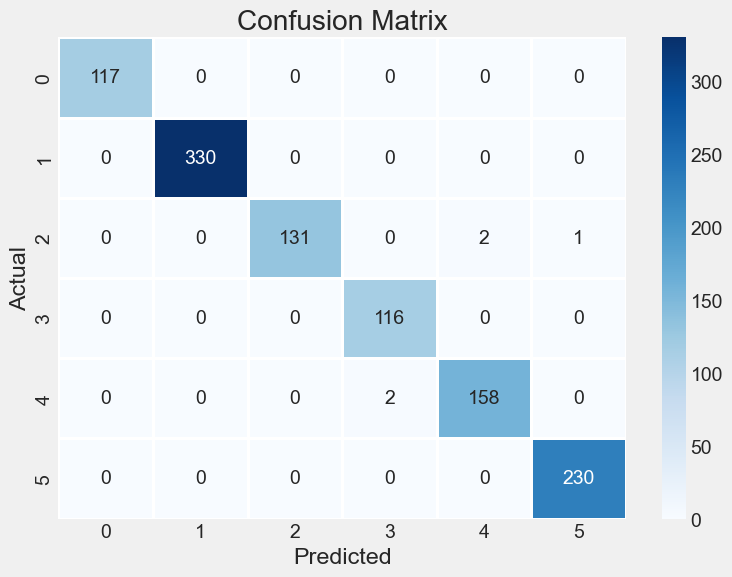

In [48]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", linewidths=1)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [49]:
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys())) # to define number of classes in dense layer

# create pre-trained model (you can build on pretrained model such as : efficientnet, VGG, Resnet)
# we will use efficientnetb3 from EfficientNet family.
base_model = tf.keras.applications.ResNet50(include_top=False, weights="imagenet", input_shape=img_shape, pooling='max')
# base_model.trainable = False

model = Sequential([
    base_model,
    BatchNormalization(momentum=0.99, epsilon=0.001),
    Dense(256, kernel_regularizer=regularizers.l2(0.016), activity_regularizer=regularizers.l1(0.006),
          bias_regularizer=regularizers.l1(0.006), activation='relu'),
    Dropout(rate=0.45, seed=123),
    Dense(class_count, activation='softmax')
])

model.compile(Adamax(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# model.summary()

In [39]:
model.build(input_shape=(None, *img_shape))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 2048)                │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 2048)                │           8,192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,121,990 (92.02 MB)

 Trainable params: 24,064,774 (91.80 MB)

 Non-trainable params: 57,216 (223.50 KB)

In [40]:
history = model.fit(train_gen, epochs= 5, verbose= 1, validation_data= valid_gen, shuffle= False)

Epoch 1/5
544/544 ━━━━━━━━━━━━━━━━━━━━ 2311s 4s/step - accuracy: 0.8726 - loss: 7.1851 - val_accuracy: 0.9374 - val_loss: 4.6389
Epoch 2/5
544/544 ━━━━━━━━━━━━━━━━━━━━ 30914s 57s/step - accuracy: 0.9266 - loss: 3.3818 - val_accuracy: 0.9825 - val_loss: 2.2541
Epoch 3/5
544/544 ━━━━━━━━━━━━━━━━━━━━ 2571s 5s/step - accuracy: 0.9130 - loss: 1.8500 - val_accuracy: 0.9512 - val_loss: 1.7801
Epoch 4/5
544/544 ━━━━━━━━━━━━━━━━━━━━ 2524s 5s/step - accuracy: 0.9195 - loss: 1.2412 - val_accuracy: 0.9844 - val_loss: 0.8506
Epoch 5/5
544/544 ━━━━━━━━━━━━━━━━━━━━ 2536s 5s/step - accuracy: 0.9259 - loss: 0.9725 - val_accuracy: 0.9871 - val_loss: 0.7095


In [41]:
model.save("resnet50_model.keras")

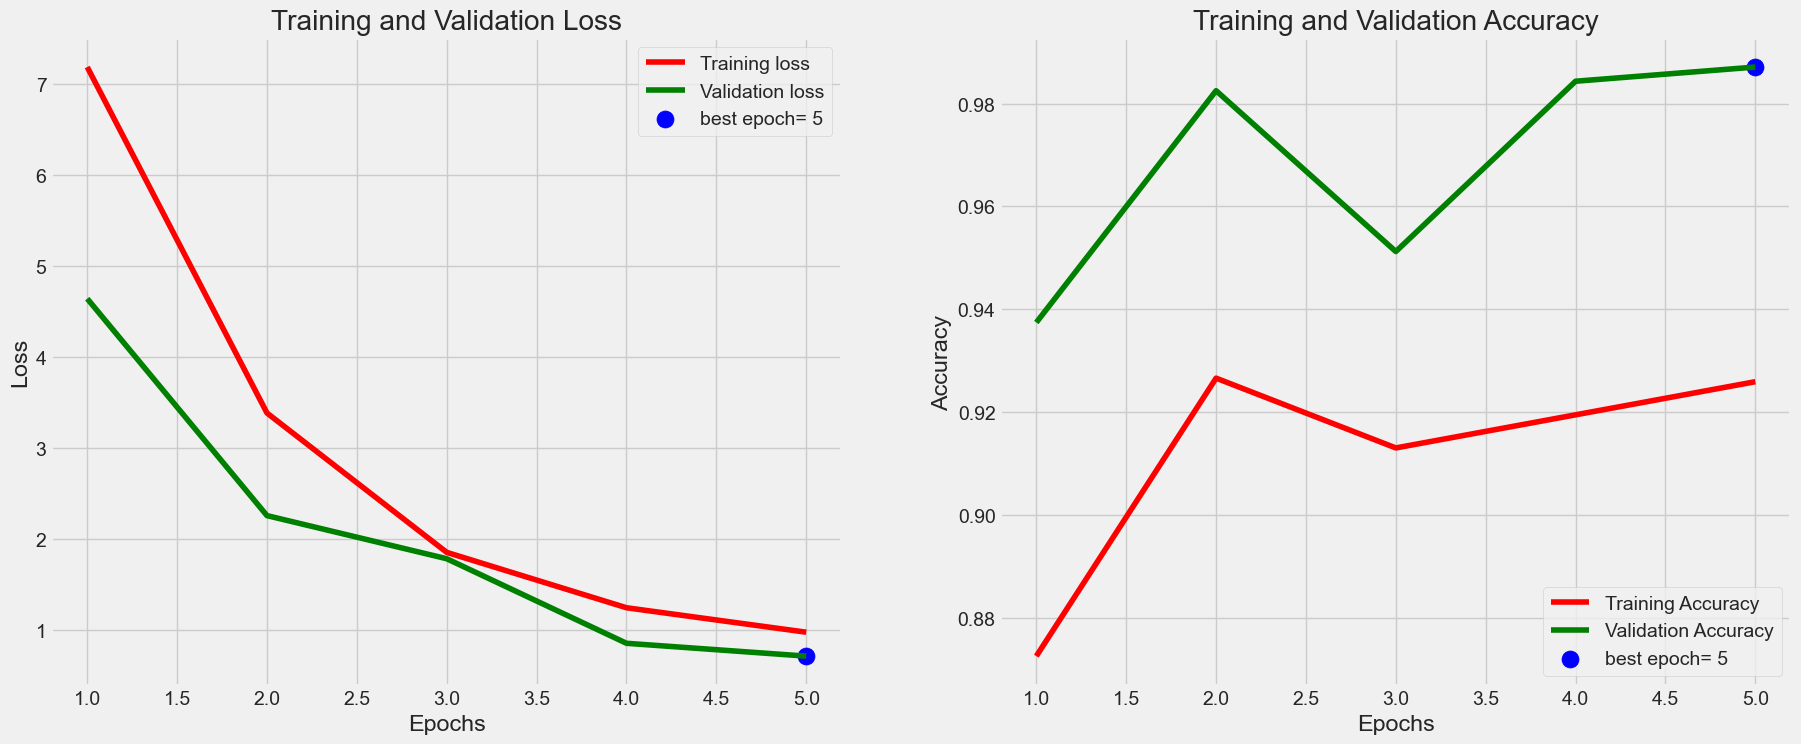

In [42]:
# Define needed variables
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [43]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

1087/1087 ━━━━━━━━━━━━━━━━━━━━ 615s 565ms/step - accuracy: 0.9934 - loss: 0.6947
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 82s 74ms/step - accuracy: 0.9871 - loss: 0.7095
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 82s 74ms/step - accuracy: 0.9862 - loss: 0.7092
Train Loss:  0.6946806311607361
Train Accuracy:  0.9934437274932861
--------------------
Validation Loss:  0.7094800472259521
Validation Accuracy:  0.987120509147644
--------------------
Test Loss:  0.7091642618179321
Test Accuracy:  0.9862005710601807


In [44]:
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

68/68 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step


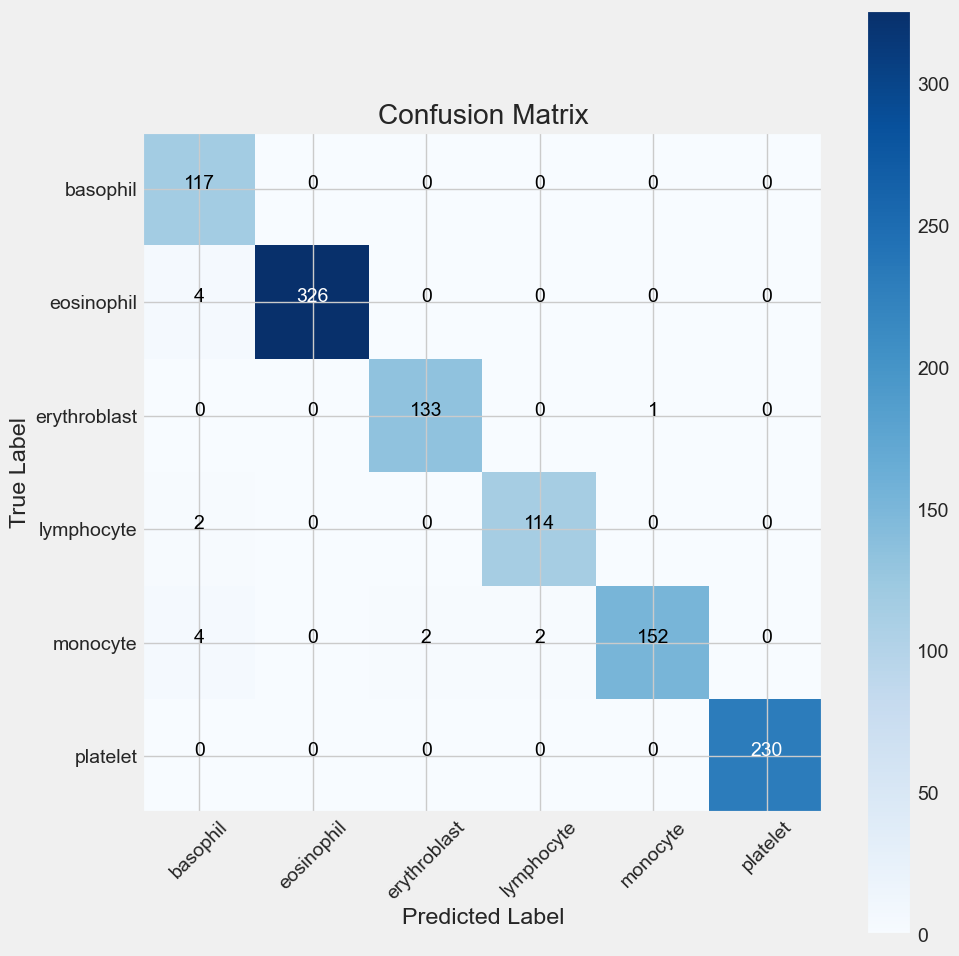

In [45]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [46]:
print(classification_report(test_gen.classes, y_pred, target_names= classes))

              precision    recall  f1-score   support

    basophil       0.92      1.00      0.96       117
  eosinophil       1.00      0.99      0.99       330
erythroblast       0.99      0.99      0.99       134
  lymphocyte       0.98      0.98      0.98       116
    monocyte       0.99      0.95      0.97       160
    platelet       1.00      1.00      1.00       230

    accuracy                           0.99      1087
   macro avg       0.98      0.99      0.98      1087
weighted avg       0.99      0.99      0.99      1087



In [47]:
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys())) # to define number of classes in dense layer

# create pre-trained model (you can build on pretrained model such as : efficientnet, VGG, Resnet)
# we will use efficientnetb3 from EfficientNet family.
base_model = tf.keras.applications.MobileNetV2(include_top=False, weights="imagenet", input_shape=img_shape, pooling='max')
# base_model.trainable = False

model = Sequential([
    base_model,
    BatchNormalization(momentum=0.99, epsilon=0.001),
    Dense(256, kernel_regularizer=regularizers.l2(0.016), activity_regularizer=regularizers.l1(0.006),
          bias_regularizer=regularizers.l1(0.006), activation='relu'),
    Dropout(rate=0.45, seed=123),
    Dense(class_count, activation='softmax')
])

model.compile(Adamax(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# model.summary()

In [48]:
model.build(input_shape=(None, *img_shape))
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 1280)                │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,592,582 (9.89 MB)

 Trainable params: 2,555,910 (9.75 MB)

 Non-trainable params: 36,672 (143.25 KB)

In [49]:
history = model.fit(train_gen, epochs= 6, verbose= 1, validation_data= valid_gen, shuffle= False)

Epoch 1/6
544/544 ━━━━━━━━━━━━━━━━━━━━ 807s 1s/step - accuracy: 0.8214 - loss: 7.2549 - val_accuracy: 0.6891 - val_loss: 4.9964
Epoch 2/6
544/544 ━━━━━━━━━━━━━━━━━━━━ 821s 1s/step - accuracy: 0.9283 - loss: 3.0663 - val_accuracy: 0.9052 - val_loss: 2.0612
Epoch 3/6
544/544 ━━━━━━━━━━━━━━━━━━━━ 810s 1s/step - accuracy: 0.9436 - loss: 1.6026 - val_accuracy: 0.9770 - val_loss: 1.1043
Epoch 4/6
544/544 ━━━━━━━━━━━━━━━━━━━━ 863s 1s/step - accuracy: 0.9482 - loss: 1.0990 - val_accuracy: 0.9678 - val_loss: 0.8449
Epoch 5/6
544/544 ━━━━━━━━━━━━━━━━━━━━ 844s 1s/step - accuracy: 0.9515 - loss: 0.9112 - val_accuracy: 0.9807 - val_loss: 0.7084
Epoch 6/6
544/544 ━━━━━━━━━━━━━━━━━━━━ 1546s 3s/step - accuracy: 0.9538 - loss: 0.8226 - val_accuracy: 0.9448 - val_loss: 0.7487


In [50]:
model.save("mobienetv2_model.keras")

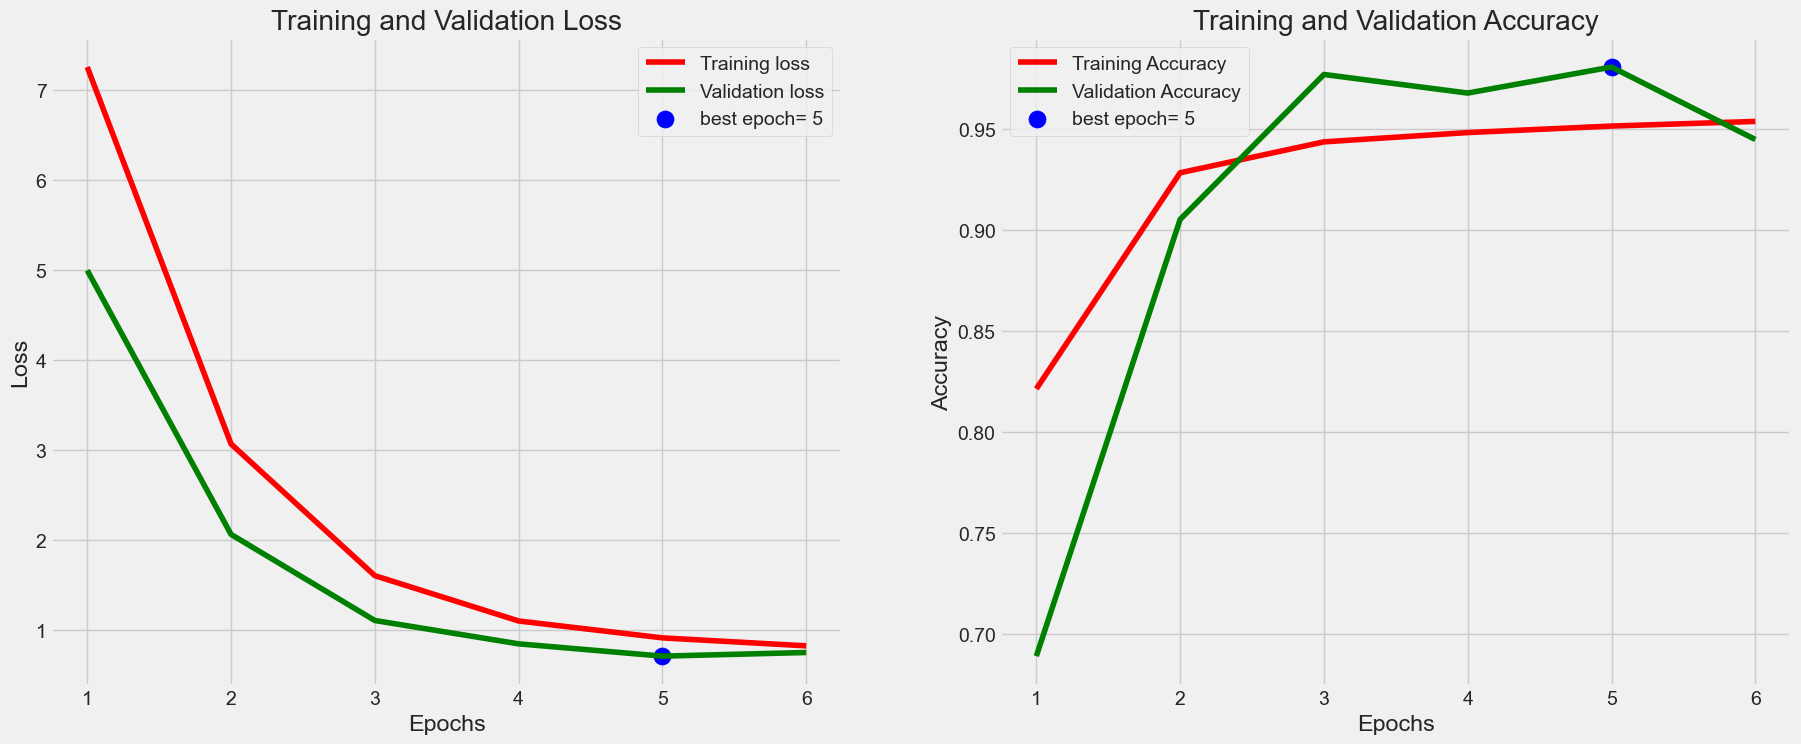

In [51]:
# Define needed variables
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [52]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

1087/1087 ━━━━━━━━━━━━━━━━━━━━ 151s 139ms/step - accuracy: 0.9524 - loss: 0.7254
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.9448 - loss: 0.7487  
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.9402 - loss: 0.7337  
Train Loss:  0.7254267930984497
Train Accuracy:  0.9523809552192688
--------------------
Validation Loss:  0.7486986517906189
Validation Accuracy:  0.9448022246360779
--------------------
Test Loss:  0.7336933612823486
Test Accuracy:  0.9402024149894714


In [53]:
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

68/68 ━━━━━━━━━━━━━━━━━━━━ 22s 308ms/step


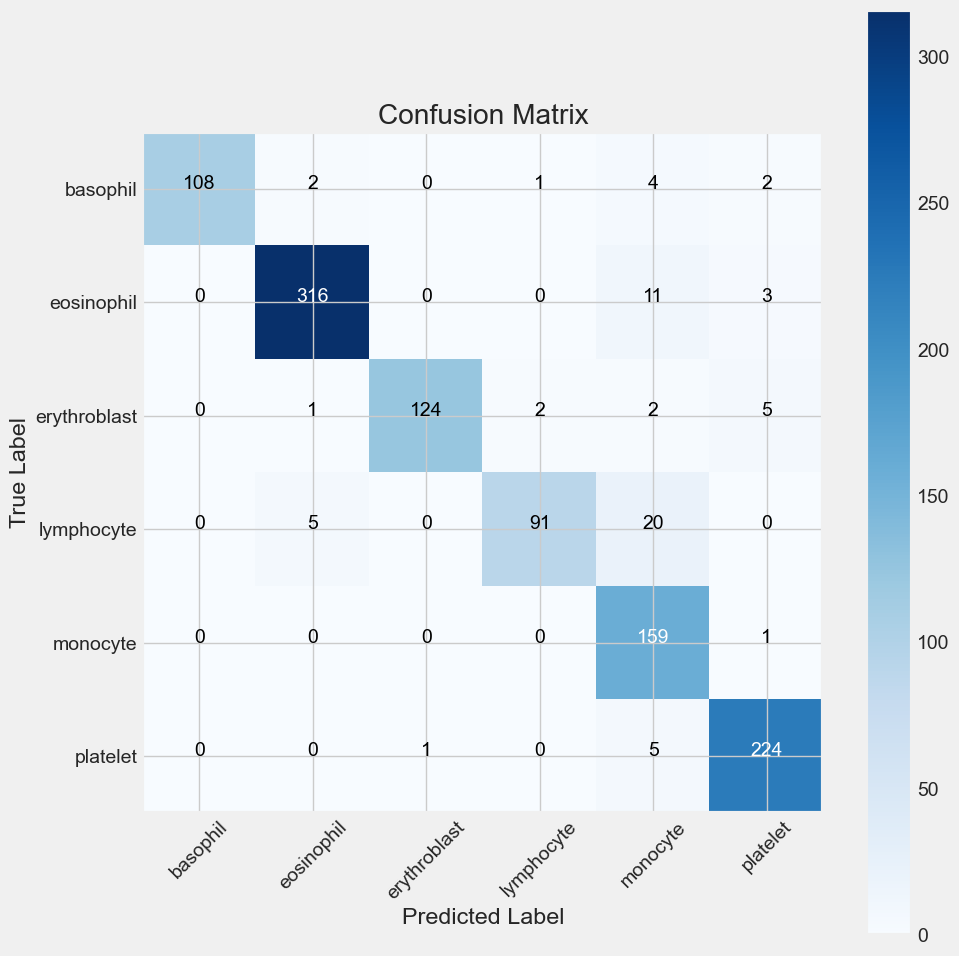

In [54]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [86]:
print(classification_report(test_gen.classes, y_pred, target_names= classes))

              precision    recall  f1-score   support

    basophil       1.00      0.95      0.97       117
  eosinophil       1.00      1.00      1.00       330
erythroblast       0.99      1.00      0.99       134
  lymphocyte       0.97      0.99      0.98       116
    monocyte       0.99      0.99      0.99       160
    platelet       1.00      1.00      1.00       230

    accuracy                           0.99      1087
   macro avg       0.99      0.99      0.99      1087
weighted avg       0.99      0.99      0.99      1087



68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 292ms/step


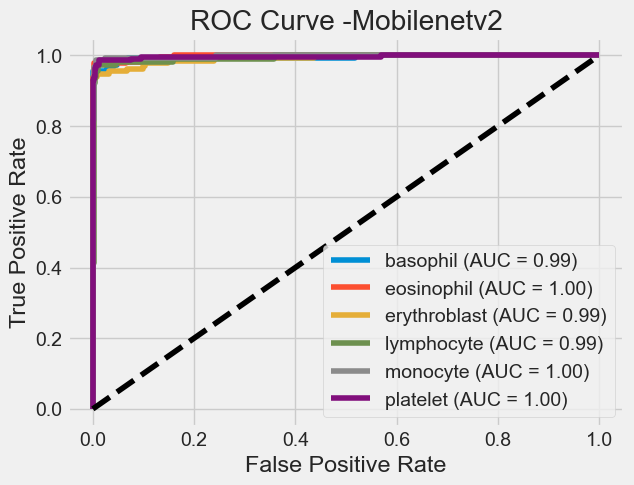

In [56]:
# get prediction probabilities
y_prob = model.predict(test_gen)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()

class_names = list(train_gen.class_indices.keys())

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve -Mobilenetv2")
plt.legend()
plt.show()

In [57]:
import numpy as np

dummy = np.zeros((1,224,224,3))
model.predict(dummy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[0.01220631, 0.01961962, 0.02022402, 0.01422998, 0.0132406 ,
        0.9204794 ]], dtype=float32)

In [58]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [59]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3),
    pooling='avg'
)

In [60]:
batch_size = 16
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

# Image generators
tr_gen = ImageDataGenerator(rescale=1./255)
ts_gen = ImageDataGenerator(rescale=1./255)

# Training generator
train_gen = tr_gen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,        # IMPORTANT for SVM
    batch_size=batch_size
)

# Validation generator
valid_gen = ts_gen.flow_from_dataframe(
    dataframe=valid_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)

# Test generator
test_gen = ts_gen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)

Found 8694 validated image filenames belonging to 6 classes.
Found 1087 validated image filenames belonging to 6 classes.
Found 1087 validated image filenames belonging to 6 classes.


In [61]:
train_features = base_model.predict(train_gen) #fetaure extraction
valid_features = base_model.predict(valid_gen)
test_features = base_model.predict(test_gen)

544/544 ━━━━━━━━━━━━━━━━━━━━ 155s 283ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 19s 281ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 19s 285ms/step


In [62]:
train_labels = train_gen.classes
valid_labels = valid_gen.classes
test_labels = test_gen.classes

In [63]:
svm = SVC(kernel='rbf')

svm.fit(train_features, train_labels)  #train svm

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [64]:
predictions = svm.predict(test_features)

In [65]:
print("Accuracy:", accuracy_score(test_labels, predictions))

print("\nClassification Report")
print(classification_report(test_labels, predictions))

Accuracy: 0.9466421343146274

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       117
           1       0.96      0.98      0.97       330
           2       0.94      0.93      0.93       134
           3       0.88      0.91      0.89       116
           4       0.96      0.90      0.93       160
           5       0.97      0.97      0.97       230

    accuracy                           0.95      1087
   macro avg       0.94      0.94      0.94      1087
weighted avg       0.95      0.95      0.95      1087



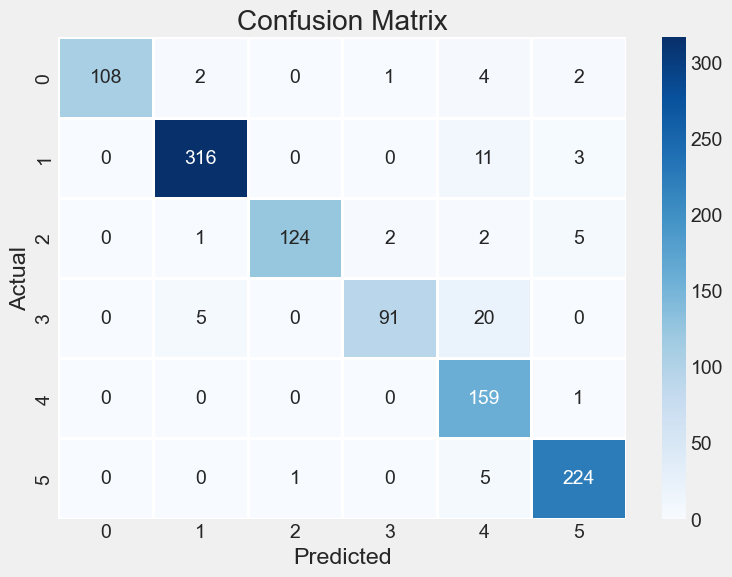

In [66]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", linewidths=1)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()